# Máquinas Térmicas — Lección 1
## Procesos termodinámicos politrópicos y trabajo de frontera móvil


### Objetivos de aprendizaje
1. **Definir** $Pv^{n}=C$ y sus casos ($n=0,1,k,\infty$).
2. **Calcular** el trabajo de frontera $W=\int_1^2 P\,dV$ (integral y forma cerrada).
3. **Interpretar** procesos en $P\text{-}v$ y $T\text{-}s$, incluido el domo de saturación (CoolProp).
4. **Analizar** cómo $n$ minimiza o maximiza el trabajo.


### Prerrequisitos
Sistema cerrado y Primera Ley $\Delta U = Q - W$ · cálculo integral · Python con `numpy`/`matplotlib`.


In [1]:
# === Bootstrap del entorno ===================================================
# Este notebook se ejecuta igual en LOCAL y en GOOGLE COLAB.
#  - Local: usar el kernel "Python (ThermalMachines)" (venv env/.venv); ya trae todo.
#  - Colab: falta CoolProp -> se instala automáticamente aquí abajo.
import sys, subprocess, importlib

def _ensure(pip_name, import_name=None):
    """Instala pip_name solo si no puede importarse (idempotente)."""
    try:
        importlib.import_module(import_name or pip_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True)

if "google.colab" in sys.modules:      # entorno Colab: completar lo que falta
    _ensure("CoolProp", "CoolProp")
    _ensure("ipywidgets", "ipywidgets")

print("Entorno listo · Python", sys.version.split()[0])


Entorno listo · Python 3.11.4


In [2]:
# === Setup: librerías, constantes y helpers reutilizables ===================
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# np.trapezoid (NumPy>=2.0) o np.trapz (NumPy 1.x): usar el que exista.
# OJO: np.trapz fue ELIMINADO en NumPy 2.x, por eso no se usa como default de
# getattr (se evaluaría de forma ansiosa y fallaría). Así corre en local y Colab.
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

# --- Gas ideal de referencia (aire) ----------------------------------------
R   = 287.0            # J/(kg·K)  constante del aire
k   = 1.4              # cp/cv
cv  = R / (k - 1)      # J/(kg·K)
cp  = k * cv           # J/(kg·K)

def estado2_politropico(P1, T1, rv, n):
    """Estado 2 de un politrópico Pv^n=C dado v2/v1=rv (por unidad de masa)."""
    v1 = R * T1 / P1
    v2 = rv * v1
    if np.isinf(n):                       # isocórico
        v2 = v1
        P2 = P1                            # (se ajusta por T aparte)
    else:
        P2 = P1 * (v1 / v2) ** n
    T2 = P2 * v2 / R
    return v1, v2, P2, T2

def W_politropico(P1, v1, P2, v2, n):
    """Trabajo específico de frontera [J/kg] en un politrópico."""
    if np.isclose(n, 1.0):
        return P1 * v1 * np.log(v2 / v1)
    return (P2 * v2 - P1 * v1) / (1 - n)

def camino_politropico(P1, T1, rv, n, N=200):
    """Trayectoria (v, P, T, s) del politrópico para graficar P-v y T-s."""
    v1 = R * T1 / P1
    v = np.linspace(v1, rv * v1, N)
    P = P1 * (v1 / v) ** n
    T = P * v / R
    s = cp * np.log(T / T1) - R * np.log(P / P1)   # s1 = 0 (referencia)
    return v, P, T, s

def plot_dome(fluid, ax, diag="Pv"):
    """Dibuja el domo de saturación (Q=0 y Q=1) en 'Pv' o 'Ts'."""
    Tt = PropsSI("Ttriple", fluid) + 0.1
    Tc = PropsSI("Tcrit", fluid) - 0.1
    Ts = np.linspace(Tt, Tc, 250)
    vf = 1 / np.array([PropsSI("D", "T", T, "Q", 0, fluid) for T in Ts])
    vg = 1 / np.array([PropsSI("D", "T", T, "Q", 1, fluid) for T in Ts])
    sf = np.array([PropsSI("S", "T", T, "Q", 0, fluid) for T in Ts]) / 1e3
    sg = np.array([PropsSI("S", "T", T, "Q", 1, fluid) for T in Ts]) / 1e3
    Ps = np.array([PropsSI("P", "T", T, "Q", 0, fluid) for T in Ts]) / 1e3
    if diag == "Pv":
        ax.plot(vf, Ps, "b-", lw=1.5); ax.plot(vg, Ps, "r-", lw=1.5, label="domo")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("$v$ [m³/kg]"); ax.set_ylabel("$P$ [kPa]")
    else:
        ax.plot(sf, Ts - 273.15, "b-", lw=1.5); ax.plot(sg, Ts - 273.15, "r-", lw=1.5, label="domo")
        ax.set_xlabel("$s$ [kJ/(kg·K)]"); ax.set_ylabel("$T$ [°C]")

print("Setup OK — R = %.0f J/(kg·K), k = %.2f, cp = %.0f, cv = %.0f" % (R, k, cp, cv))


Setup OK — R = 287 J/(kg·K), k = 1.40, cp = 1005, cv = 718


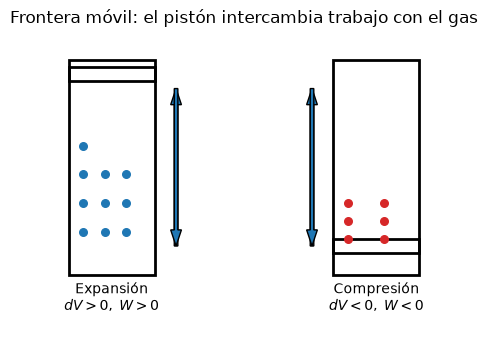

In [3]:
# Esquema conceptual: trabajo de frontera móvil (expansión vs compresión)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

fig, ax = plt.subplots(figsize=(7, 3.6))
cyl_w, cyl_h, space = 1.2, 3.0, 2.5

# --- Cilindro izquierdo: expansión ---
x0 = 0
ax.add_patch(Rectangle((x0, 0), cyl_w, cyl_h, fill=False, lw=2))
pist_top, pist_bot = cyl_h - 0.3, 0.3
ax.add_patch(Rectangle((x0, pist_top), cyl_w, 0.2, fill=False, lw=2))
for i in range(10):
    ax.scatter(x0 + 0.2 + (i % 3) * 0.3, 0.6 + (i // 3) * 0.4, s=30, color="tab:blue")
for dy in (1, -1):
    ax.add_patch(FancyArrow(x0 + cyl_w + 0.3, pist_bot + 0.1 if dy == 1 else pist_top - 0.1,
                            0, dy * (pist_top - pist_bot - 0.2), width=0.05,
                            head_width=0.15, length_includes_head=True))
ax.text(x0 + cyl_w / 2, -0.5, "Expansión\n$dV>0,\\;W>0$", ha="center")

# --- Cilindro derecho: compresión ---
x1 = x0 + cyl_w + space
ax.add_patch(Rectangle((x1, 0), cyl_w, cyl_h, fill=False, lw=2))
ax.add_patch(Rectangle((x1, pist_bot), cyl_w, 0.2, fill=False, lw=2))
for i in range(6):
    ax.scatter(x1 + 0.2 + (i % 2) * 0.5, 0.5 + (i // 2) * 0.25, s=30, color="tab:red")
for dy in (1, -1):
    ax.add_patch(FancyArrow(x1 - 0.3, pist_bot + 0.1 if dy == 1 else pist_top - 0.1,
                            0, dy * (pist_top - pist_bot - 0.2), width=0.05,
                            head_width=0.15, length_includes_head=True))
ax.text(x1 + cyl_w / 2, -0.5, "Compresión\n$dV<0,\\;W<0$", ha="center")

ax.set_xlim(-0.6, x1 + cyl_w + 0.6); ax.set_ylim(-0.9, cyl_h + 0.4)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Frontera móvil: el pistón intercambia trabajo con el gas")
plt.tight_layout(); plt.show()


---
## 1. Marco teórico

### 1.1 Definición del proceso politrópico
Un **proceso politrópico** cumple

$$P\,v^{\,n} = C = \text{cte},$$

con $v$ el volumen específico y $n$ el **exponente politrópico**. Los procesos elementales son casos particulares:

| Proceso | Condición | $n$ | Trabajo $w=\int P\,dv$ |
|---|---|---|---|
| Isobárico | $P=\text{cte}$ | $0$ | $P(v_2-v_1)$ |
| Isotérmico (gas ideal) | $T=\text{cte}$ | $1$ | $RT\ln(v_2/v_1)$ |
| Adiabático reversible | $Q=0$ | $k=c_p/c_v$ | $\dfrac{P_2v_2-P_1v_1}{1-k}$ |
| Isocórico | $v=\text{cte}$ | $\infty$ | $0$ |

$n$ puede ser cualquier real; su valor codifica el intercambio simultáneo de calor y trabajo.


In [4]:
# WIDGET — familia politrópica en P-v; el slider resalta la curva de exponente n
def familia_politropica(n=1.0):
    P0, V0 = 1.0, 1.0
    V = np.concatenate([np.linspace(0.25, V0, 150, endpoint=False),
                        np.linspace(V0, 2.5, 150)])
    ref = [(0, "n=0 (isobárico)", "black"),
           (1, "n=1 (isotérmico)", "tab:blue"),
           (k, f"n=k≈{k} (adiabático)", "tab:green")]
    fig, ax = plt.subplots(figsize=(6, 5))
    for nn, lab, col in ref:
        ax.plot(V, P0 * V0**nn / V**nn, "--", lw=1.4, color=col, alpha=0.6, label=lab)
    ax.plot([V0, V0], [0, 4], color="gray", lw=1.4, ls=(0, (3, 1)), alpha=0.6,
            label="n→∞ (isocórico)")
    # curva seleccionada
    ax.plot(V, P0 * V0**n / V**n, "-", lw=3, color="crimson", label=f"n = {n:.2f}")
    ax.scatter([V0], [P0], color="black", zorder=5)
    ax.set_xlim(0, 2.6); ax.set_ylim(0, 4)
    ax.set_xlabel("Volumen $V$"); ax.set_ylabel("Presión $P$")
    ax.set_title("Familia de procesos politrópicos $Pv^{n}=C$")
    ax.legend(frameon=False, fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(familia_politropica,
         n=FloatSlider(value=1.0, min=0.0, max=1.8, step=0.05, description="n"));


interactive(children=(FloatSlider(value=1.0, description='n', max=1.8, step=0.05), Output()), _dom_classes=('w…

### 1.2 Trabajo en un proceso politrópico — derivación
Sustituyendo $P=C\,v^{-n}$ en el trabajo de frontera cuasiestático:

$$W_{1\to 2}=\int_{1}^{2}P\,dv=C\int_{1}^{2}v^{-n}\,dv
=\begin{cases}\dfrac{C}{1-n}\left(v_2^{\,1-n}-v_1^{\,1-n}\right), & n\neq 1,\\[6pt]
C\,\ln\dfrac{v_2}{v_1}, & n=1.\end{cases}$$

Con $C=P_1v_1^{\,n}=P_2v_2^{\,n}$, la forma cerrada en frontera es

$$\boxed{\,W_{1\to 2}=\dfrac{P_2v_2-P_1v_1}{1-n}\,}\qquad(n\neq 1).$$

**Gas ideal** ($Pv=RT$):

$$W_{1\to 2}=\dfrac{R\,(T_2-T_1)}{1-n}=\dfrac{R\,T_1}{n-1}\left(1-\dfrac{T_2}{T_1}\right),\qquad
\dfrac{T_2}{T_1}=\left(\dfrac{P_2}{P_1}\right)^{\frac{n-1}{n}},$$

$$\boxed{\,W_{1\to 2}=\dfrac{R\,T_1}{n-1}\left[1-\left(\dfrac{P_2}{P_1}\right)^{\frac{n-1}{n}}\right]\,}.$$

| Forma | Expresión |
|---|---|
| General | $W=\dfrac{C}{1-n}\left(v_2^{1-n}-v_1^{1-n}\right)$ |
| $P,v$ | $W=\dfrac{P_2v_2-P_1v_1}{1-n}$ |
| Gas ideal ($T$) | $W=\dfrac{R(T_2-T_1)}{1-n}$ |
| Gas ideal ($P$) | $W=\dfrac{RT_1}{n-1}\left[1-(P_2/P_1)^{(n-1)/n}\right]$ |


### 1.3 El trabajo es el área bajo $P\text{-}v$: las cuatro integrales
$w=\int_{v_1}^{v_2}P\,dv$ es el **área bajo la trayectoria** en $P\text{-}v$:

$$
\underbrace{\int_{v_1}^{v_2}\!P\,dv}_{\text{isobárico }(n=0)}=P\,(v_2-v_1),\qquad
\underbrace{\int_{v_1}^{v_2}\!\frac{RT}{v}\,dv}_{\text{isotérmico }(n=1)}=RT\ln\frac{v_2}{v_1},
$$

$$
\underbrace{\int_{v_1}^{v_2}\!Cv^{-k}\,dv}_{\text{adiabático }(n=k)}=\frac{P_2v_2-P_1v_1}{1-k},\qquad
\underbrace{\int P\,dv}_{\text{isocórico }(n\to\infty)}=0\;(dv=0).
$$

El widget siguiente aproxima la integral por **trapecios** y la compara con la fórmula cerrada.


In [ ]:
# WIDGET — trabajo: integral numérica (trapecio) vs fórmula cerrada
def area_vs_integral(n=1.3, P1_kPa=100.0, V1=0.02, rv=2.0, N=8):
    P1 = P1_kPa * 1e3
    V1_ = V1; V2 = rv * V1_
    Vf = np.linspace(V1_, V2, 400)
    Pf = P1 * (V1_ / Vf) ** n
    P2 = P1 * (V1_ / V2) ** n

    # integral numérica con N subintervalos visibles
    Vn = np.linspace(V1_, V2, N + 1)
    Pn = P1 * (V1_ / Vn) ** n
    W_num = trapz(Pn, Vn)
    W_ana = W_politropico(P1, V1_, P2, V2, n)   # J
    err = 100 * abs(W_num - W_ana) / abs(W_ana) if W_ana else 0.0

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(Vf, Pf / 1e3, color="darkblue", lw=2)
    ax.fill_between(Vf, 0, Pf / 1e3, color="skyblue", alpha=0.4, label="área exacta = W")
    # trapecios
    for i in range(N):
        ax.fill_between([Vn[i], Vn[i+1]], [Pn[i]/1e3, Pn[i+1]/1e3],
                        color="orange", alpha=0.25, edgecolor="orange")
    ax.scatter([V1_, V2], [P1/1e3, P2/1e3], color="black", zorder=5)
    ax.set_xlabel("Volumen $V$ [m³]"); ax.set_ylabel("Presión $P$ [kPa]")
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)
    ax.set_title("Trabajo = área bajo $P$-$V$")
    txt = (f"n = {n:.2f}\n"
           f"$W_{{analítico}}$ = {W_ana/1000:.3f} kJ\n"
           f"$W_{{trapecio,N={N}}}$ = {W_num/1000:.3f} kJ\n"
           f"error = {err:.2f} %")
    ax.text(0.97, 0.95, txt, transform=ax.transAxes, ha="right", va="top",
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8), fontsize=10)
    ax.legend(loc="lower left", fontsize=9); plt.tight_layout(); plt.show()

interact(area_vs_integral,
         n=FloatSlider(1.3, min=0.0, max=1.8, step=0.05, description="n"),
         P1_kPa=FloatSlider(100, min=50, max=500, step=10, description="P₁ [kPa]"),
         V1=FloatSlider(0.02, min=0.01, max=0.05, step=0.005, description="V₁ [m³]", readout_format=".3f"),
         rv=FloatSlider(2.0, min=0.4, max=3.0, step=0.1, description="V₂/V₁"),
         N=IntSlider(8, min=2, max=40, step=1, description="N trap."));


interactive(children=(FloatSlider(value=1.3, description='n', max=1.8, step=0.05), FloatSlider(value=100.0, de…

### 1.4 Explorador de procesos en $P\text{-}v$ y $T\text{-}s$ (gas ideal, aire)
Ajusta $n$, $(P_1,T_1)$ y $v_2/v_1$; se recalculan el estado 2, $w$, $q=\Delta u+w$ y $\Delta u=c_v\,\Delta T$.


In [ ]:
# WIDGET — explorador de procesos: P-v y T-s simultáneos (gas ideal)
def explorador(n=1.0, P1_kPa=100.0, T1_C=27.0, rv=0.5):
    P1 = P1_kPa * 1e3; T1 = T1_C + 273.15
    v1, v2, P2, T2 = estado2_politropico(P1, T1, rv, n)
    v, P, T, s = camino_politropico(P1, T1, rv, n)
    w = W_politropico(P1, v1, P2, v2, n)          # J/kg
    du = cv * (T2 - T1); q = du + w

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
    # P-v
    ax1.plot(v, P/1e3, "crimson", lw=2)
    ax1.fill_between(v, 0, P/1e3, color="mistyrose", alpha=0.7)
    ax1.scatter([v1, v2], [P1/1e3, P2/1e3], color="black", zorder=5)
    ax1.text(v1, P1/1e3, " 1", va="bottom"); ax1.text(v2, P2/1e3, " 2", va="top")
    ax1.set_xlabel("$v$ [m³/kg]"); ax1.set_ylabel("$P$ [kPa]")
    ax1.set_xlim(left=0); ax1.set_ylim(bottom=0); ax1.set_title("Diagrama $P$-$v$")
    ax1.grid(alpha=0.3)
    # T-s
    ax2.plot(s/1e3, T - 273.15, "teal", lw=2)
    ax2.scatter([0, s[-1]/1e3], [T1-273.15, T2-273.15], color="black", zorder=5)
    ax2.text(0, T1-273.15, " 1", va="bottom"); ax2.text(s[-1]/1e3, T2-273.15, " 2", va="top")
    ax2.set_xlabel("$s-s_1$ [kJ/(kg·K)]"); ax2.set_ylabel("$T$ [°C]")
    ax2.set_title("Diagrama $T$-$s$"); ax2.grid(alpha=0.3)

    proc = {0: "isobárico", 1: "isotérmico"}.get(round(n, 2),
           "adiabático" if np.isclose(n, k) else "politrópico")
    fig.suptitle(f"Proceso {proc} (n={n:.2f}):  "
                 f"w={w/1000:.2f} kJ/kg,  q={q/1000:.2f} kJ/kg,  Δu={du/1000:.2f} kJ/kg,  "
                 f"T₂={T2-273.15:.1f} °C", fontsize=10)
    plt.tight_layout(); plt.show()

interact(explorador,
         n=FloatSlider(1.0, min=0.0, max=1.8, step=0.05, description="n"),
         P1_kPa=FloatSlider(100, min=50, max=500, step=10, description="P₁ [kPa]"),
         T1_C=FloatSlider(27, min=0, max=300, step=5, description="T₁ [°C]"),
         rv=FloatSlider(0.5, min=0.3, max=3.0, step=0.1, description="V₂/V₁"));


interactive(children=(FloatSlider(value=1.0, description='n', max=1.8, step=0.05), FloatSlider(value=100.0, de…

### 1.5 Procesos reales sobre el domo de saturación del agua (CoolProp)
Un fluido real cambia de fase. El widget traza un proceso **isobárico** o **isotérmico** del agua en $P\text{-}v$ y $T\text{-}s$ sobre el domo, con propiedades reales de CoolProp.


In [ ]:
# WIDGET — proceso real del agua sobre el domo (P-v y T-s con CoolProp)
def proceso_agua(tipo="isobárico", P_kPa=200.0, T_C=200.0, T_ini_C=20.0, T_fin_C=400.0):
    F = "Water"
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
    plot_dome(F, ax1, "Pv"); plot_dome(F, ax2, "Ts")

    if tipo == "isobárico":
        P = P_kPa * 1e3
        Ts = np.linspace(T_ini_C, T_fin_C, 120) + 273.15
        v = 1 / np.array([PropsSI("D", "P", P, "T", T, F) for T in Ts])
        s = np.array([PropsSI("S", "P", P, "T", T, F) for T in Ts]) / 1e3
        Pp = np.full_like(Ts, P) / 1e3
        etiqueta = f"isobárico @ {P_kPa:.0f} kPa"
    else:  # isotérmico
        T = T_C + 273.15
        Pmin = PropsSI("P", "T", T, "Q", 0, F) * 0.2 if T < PropsSI("Tcrit", F) else 5e4
        Ps = np.linspace(Pmin, 1.5e7, 120)
        v = 1 / np.array([PropsSI("D", "T", T, "P", P, F) for P in Ps])
        s = np.array([PropsSI("S", "T", T, "P", P, F) for P in Ps]) / 1e3
        Pp = Ps / 1e3
        Ts = np.full_like(Ps, T)
        etiqueta = f"isotérmico @ {T_C:.0f} °C"

    ax1.plot(v, Pp, "k-", lw=2, label=etiqueta)
    ax2.plot(s, Ts - 273.15, "k-", lw=2, label=etiqueta)
    ax1.legend(fontsize=8, loc="upper right"); ax2.legend(fontsize=8, loc="lower right")
    ax1.set_title("Agua — $P$-$v$"); ax2.set_title("Agua — $T$-$s$")
    plt.tight_layout(); plt.show()

interact(proceso_agua,
         tipo=Dropdown(options=["isobárico", "isotérmico"], value="isobárico", description="proceso"),
         P_kPa=FloatSlider(200, min=20, max=15000, step=50, description="P [kPa]"),
         T_C=FloatSlider(200, min=20, max=350, step=10, description="T [°C]"),
         T_ini_C=FloatSlider(20, min=5, max=200, step=5, description="T inicial [°C]"),
         T_fin_C=FloatSlider(400, min=250, max=600, step=10, description="T final [°C]"));


interactive(children=(Dropdown(description='proceso', options=('isobárico', 'isotérmico'), value='isobárico'),…

---
## 2. Los cuatro procesos elementales

### 2.1 Isobárico ($n=0$, $P=\text{cte}$)
$$W=\int_1^2 P\,dV=P\,(V_2-V_1)=mR\,(T_2-T_1).$$
Área rectangular en $P\text{-}v$; expansión $\Rightarrow W>0$.


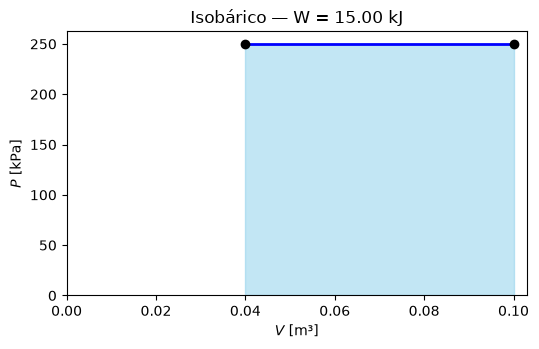

W analítico = 15.000 kJ | W trapecio = 15.000 kJ | T1=35 K, T2=87 K


In [8]:
# Ejemplo isobárico (aire, m=1 kg): P=250 kPa, V: 0.04 -> 0.10 m³
P = 250e3; V1, V2 = 0.04, 0.10; m = 1.0
W_ana = P * (V2 - V1)
V = np.linspace(V1, V2, 50); Pline = np.full_like(V, P)
W_num = trapz(Pline, V)
T1 = P * V1 / (m * R); T2 = P * V2 / (m * R)

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(V, Pline/1e3, "b", lw=2)
ax.fill_between(V, 0, Pline/1e3, color="skyblue", alpha=0.5)
ax.scatter([V1, V2], [P/1e3, P/1e3], color="k", zorder=5)
ax.set_xlabel("$V$ [m³]"); ax.set_ylabel("$P$ [kPa]")
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.set_title(f"Isobárico — W = {W_ana/1000:.2f} kJ")
plt.tight_layout(); plt.show()
print(f"W analítico = {W_ana/1000:.3f} kJ | W trapecio = {W_num/1000:.3f} kJ | T1={T1:.0f} K, T2={T2:.0f} K")


### 2.2 Isotérmico ($n=1$, $T=\text{cte}$)
Con $P=mRT/V$,
$$W=\int_1^2\frac{mRT}{V}\,dV=mRT\,\ln\frac{V_2}{V_1}=mRT\,\ln\frac{P_1}{P_2}.$$
Área bajo la hipérbola $P\propto 1/V$.


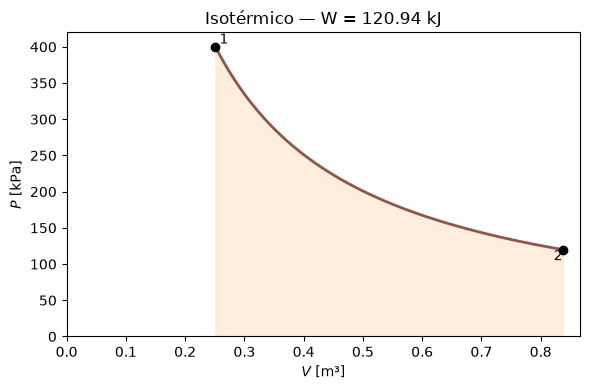

W analítico = 120.939 kJ | W trapecio = 120.940 kJ


In [9]:
# Ejemplo isotérmico (aire, m=1 kg): T=350 K, P: 400 -> 120 kPa
m = 1.0; T = 350.0
P1, P2 = 400e3, 120e3
V1 = m * R * T / P1; V2 = m * R * T / P2
V = np.linspace(V1, V2, 300); P = m * R * T / V
W_ana = m * R * T * np.log(V2 / V1)
W_num = trapz(P, V)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(V, P/1e3, color="tab:brown", lw=2)
ax.fill_between(V, 0, P/1e3, color="bisque", alpha=0.6)
ax.scatter([V1, V2], [P1/1e3, P2/1e3], color="k", zorder=5)
ax.text(V1, P1/1e3, " 1", va="bottom"); ax.text(V2, P2/1e3, " 2", va="top", ha="right")
ax.set_xlabel("$V$ [m³]"); ax.set_ylabel("$P$ [kPa]")
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.set_title(f"Isotérmico — W = {W_ana/1000:.2f} kJ")
plt.tight_layout(); plt.show()
print(f"W analítico = {W_ana/1000:.3f} kJ | W trapecio = {W_num/1000:.3f} kJ")


### 2.3 Isocórico ($n\to\infty$, $V=\text{cte}$)
Como $dV=0$,
$$\boxed{W=\int_1^2 P\,dV=0.}$$
Toda la energía va como calor: $\Delta U=Q=m\,c_v\,(T_2-T_1)$. Recta vertical (área nula).


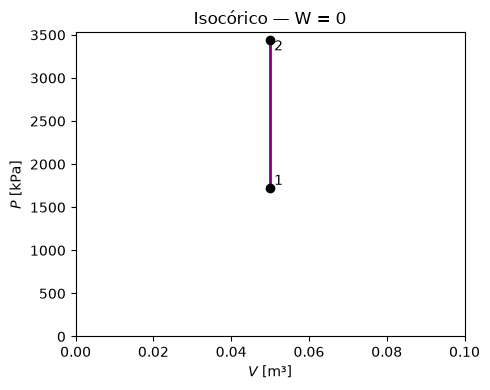

W analítico = 0.000 kJ | W trapecio = 0.000000 kJ (≈0) | ΔU = Q = 215.3 kJ


In [10]:
# Ejemplo isocórico (aire, m=1 kg): V=0.05 m³, T: 300 -> 600 K
m = 1.0; V = 0.05; T1, T2 = 300.0, 600.0
P1 = m * R * T1 / V; P2 = m * R * T2 / V
Pcurve = np.linspace(P1, P2, 200); Vcurve = np.full_like(Pcurve, V)
W_ana = 0.0; W_num = trapz(Pcurve, Vcurve)
dU = m * cv * (T2 - T1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(Vcurve, Pcurve/1e3, "purple", lw=2)
ax.scatter([V, V], [P1/1e3, P2/1e3], color="k", zorder=5)
ax.text(V, P1/1e3, " 1", va="bottom"); ax.text(V, P2/1e3, " 2", va="top")
ax.set_xlabel("$V$ [m³]"); ax.set_ylabel("$P$ [kPa]")
ax.set_xlim(0, 2*V); ax.set_ylim(bottom=0)
ax.set_title("Isocórico — W = 0")
plt.tight_layout(); plt.show()
print(f"W analítico = {W_ana:.3f} kJ | W trapecio = {W_num/1000:.6f} kJ (≈0) | ΔU = Q = {dU/1000:.1f} kJ")


### 2.4 Reflexión: ¿qué $n$ minimiza o maximiza el trabajo?
Al **comprimir** de $P_1$ a $P_2>P_1$, el trabajo de entrada $w_{in}=-w$ crece con $n$:

$$w_{in}(n)=\frac{R\,T_1}{n-1}\left[\left(\frac{P_2}{P_1}\right)^{\frac{n-1}{n}}-1\right].$$

- **Isotérmico ($n=1$):** $w_{in}$ mínimo (el calor retirado frena el alza de presión).
- **Adiabático ($n=k$):** $w_{in}$ máximo (sin extraer calor, $T$ y $P$ suben más).

Por eso los compresores se **refrigeran** (interenfriamiento), acercándose al límite isotérmico.


In [11]:
# WIDGET — w_in(n) en compresión: mínimo isotérmico vs máximo adiabático
def trabajo_vs_n(ratio_P=5.0, T1_C=27.0):
    T1 = T1_C + 273.15; r = ratio_P
    n = np.linspace(0.4, 1.8, 300)
    w_in = np.where(np.isclose(n, 1.0),
                    R * T1 * np.log(r),
                    R * T1 / (n - 1) * (r ** ((n - 1) / n) - 1))
    w_iso = R * T1 * np.log(r)
    w_adi = R * T1 / (k - 1) * (r ** ((k - 1) / k) - 1)

    fig, ax = plt.subplots(figsize=(7, 4.3))
    ax.plot(n, w_in / 1000, lw=2, color="navy")
    ax.axvline(1.0, ls="--", color="tab:blue", alpha=0.7)
    ax.axvline(k, ls="--", color="tab:green", alpha=0.7)
    ax.scatter([1.0, k], [w_iso/1000, w_adi/1000], color="red", zorder=5)
    ax.annotate(f"isotérmico (mín)\n{w_iso/1000:.1f} kJ/kg", (1.0, w_iso/1000),
                textcoords="offset points", xytext=(10, -25), fontsize=9)
    ax.annotate(f"adiabático (máx)\n{w_adi/1000:.1f} kJ/kg", (k, w_adi/1000),
                textcoords="offset points", xytext=(-20, 15), fontsize=9)
    ax.set_xlabel("exponente politrópico $n$")
    ax.set_ylabel("trabajo de compresión $w_{in}$ [kJ/kg]")
    ax.set_title(f"Compresión $P_2/P_1$ = {r:.1f} · a mayor $n$, mayor trabajo de entrada")
    ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

interact(trabajo_vs_n,
         ratio_P=FloatSlider(5.0, min=2.0, max=15.0, step=0.5, description="P₂/P₁"),
         T1_C=FloatSlider(27, min=0, max=200, step=5, description="T₁ [°C]"));


interactive(children=(FloatSlider(value=5.0, description='P₂/P₁', max=15.0, min=2.0, step=0.5), FloatSlider(va…

> ### 🔬 Conexión con la práctica: eficiencia politrópica de compresores
> La compresión real (ni isotérmica ni perfectamente adiabática) se modela **politrópica** con $n$ efectivo ligado a la **eficiencia politrópica** $\eta_p$:
> $$\frac{n-1}{n}=\frac{1}{\eta_p}\,\frac{k-1}{k}.$$
> Medir $n$ en un ensayo $(P_1,T_1)\to(P_2,T_2)$ estima $\eta_p$. El modelo reaparece en el ciclo Brayton y en compresores reciprocantes (lecciones posteriores).


---
## 3. Función general de trabajo politrópico


Trabajo específico: -129.09 kJ/kg  (negativo = compresión)


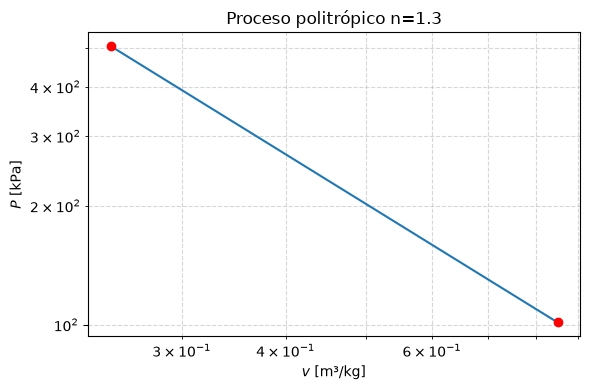

In [12]:
def trabajo_polytropic(P1, V1, P2=None, V2=None, n=1.3):
    """Trabajo de un proceso politrópico (sistema cerrado, SI: Pa, m³ -> J).

    Se provee una de las condiciones finales (P2 o V2); la otra se deduce de Pv^n=C.
    n=1 se trata como isotérmico; n=inf como isocórico (W=0).
    """
    if np.isinf(n):
        return 0.0, P2, V1
    if V2 is None and P2 is not None:
        V2 = (P1 * V1**n / P2) ** (1 / n)
    elif P2 is None and V2 is not None:
        P2 = P1 * (V1 / V2) ** n
    else:
        raise ValueError("Debe proveer exactamente uno de P2 o V2")
    W = P1 * V1 * np.log(V2 / V1) if np.isclose(n, 1) else (P2 * V2 - P1 * V1) / (1 - n)
    return W, P2, V2

# Ejemplo: compresión politrópica de aire, n=1.3, P2=5·P1
P1 = 101.3e3; T1 = 300.0; V1 = R * T1 / P1        # m³/kg
n = 1.3; P2 = 5 * P1
W, P2c, V2 = trabajo_polytropic(P1, V1, P2=P2, n=n)
print(f"Trabajo específico: {W/1000:.2f} kJ/kg  (negativo = compresión)")

V = np.logspace(np.log10(V2), np.log10(V1), 100)
P = P1 * (V1**n) / (V**n)
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(V, P/1e3)
ax.scatter([V1, V2], [P1/1e3, P2/1e3], color="red", zorder=5)
ax.set_xlabel("$v$ [m³/kg]"); ax.set_ylabel("$P$ [kPa]")
ax.set_title("Proceso politrópico n=1.3"); ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()


### 3.1 Generalización: tabla maestra del proceso politrópico
Con $\Delta u=c_v(T_2-T_1)$ y $q=\Delta u+w$ (gas ideal, por unidad de masa):

| Proceso | $n$ | $w=\int P\,dv$ | $q$ | $\Delta u$ |
|---|---|---|---|---|
| Isobárico | $0$ | $P(v_2-v_1)=R(T_2-T_1)$ | $c_p(T_2-T_1)$ | $c_v(T_2-T_1)$ |
| Isotérmico | $1$ | $RT\ln(v_2/v_1)$ | $=w$ | $0$ |
| Politrópico | $n$ | $\dfrac{R(T_2-T_1)}{1-n}$ | $\Delta u+w$ | $c_v(T_2-T_1)$ |
| Adiabático | $k$ | $\dfrac{R(T_2-T_1)}{1-k}=-\Delta u$ | $0$ | $c_v(T_2-T_1)$ |
| Isocórico | $\infty$ | $0$ | $c_v(T_2-T_1)$ | $c_v(T_2-T_1)$ |


### 3.2 Verificación cruzada (fórmula cerrada vs integración numérica)
Caso de referencia: aire comprimido $n=1.3$ desde $P_1=100$ kPa, $V_1=0.1\ \mathrm{m^3}$ hasta $P_2=600$ kPa. La **fórmula cerrada** y la **integración numérica** de $\int P\,dV$ deben coincidir con error $<1\%$.


In [13]:
# Celda de verificación: fórmula cerrada vs integral numérica de alta resolución
P1, V1 = 100e3, 0.1
n, P2 = 1.3, 600e3

# Método 1: fórmula cerrada
W_formula, P2c, V2 = trabajo_polytropic(P1, V1, P2=P2, n=n)

# Método 2 (independiente): integración numérica de ∫P dV sobre la trayectoria Pv^n=C
Vg = np.linspace(V1, V2, 20001)
Pg = P1 * (V1 / Vg) ** n
W_num = trapz(Pg, Vg)

err = 100 * abs(W_formula - W_num) / abs(W_num)
print(f"W (fórmula cerrada)   = {W_formula/1000:.4f} kJ")
print(f"W (integral numérica) = {W_num/1000:.4f} kJ")
print(f"V2 = {V2*1000:.3f} L,  Error relativo = {err:.4f} %")
assert err < 1.0, "La verificación excede el 1% de tolerancia"
print("✔ Verificación superada (error < 1%): ambos métodos concuerdan")


W (fórmula cerrada)   = -17.0692 kJ
W (integral numérica) = -17.0692 kJ
V2 = 25.201 L,  Error relativo = 0.0000 %
✔ Verificación superada (error < 1%): ambos métodos concuerdan


---
## 4. Actividades propuestas
1. **Compresión isotérmica de nitrógeno.** $P_1=200$ kPa, $T_1=300$ K, comprimido isotérmicamente hasta $P_2=600$ kPa. Calcule $w$ y compare su signo con el de una expansión.
2. **Expansión adiabática de aire.** $P_1=1$ MPa, $T_1=500$ K, $k=1.4$; se expande hasta $P_2=200$ kPa. Determine $T_2$, $v_2$ y $w$.
3. **Efecto de $n$.** Fije $P_1,V_1$ y $P_2=5P_1$; grafique $w(n)$ para $0.5\le n\le 2$ (compare con el widget 2.4) y discuta qué $n$ maximiza el gasto de energía en la compresión.

> Entregue respuestas y código en el espacio indicado del repositorio.


---
## 5. Referencias
- Çengel, Y. & Boles, M. (2015). *Termodinámica*, 8ª ed. McGraw-Hill.
- Borgnakke, C. & Sonntag, R. (2013). *Fundamentals of Thermodynamics*, 8ª ed. Wiley.
- Bell, I. et al. (2014). *CoolProp: pure and pseudo-pure fluid thermophysical property library*. Ind. Eng. Chem. Res. 53(6).
- Proyecto Jupyter — `ipywidgets`: interactividad en notebooks.
